In [1]:
import sys
from pathlib import Path

# Add src/ to sys.path regardless of where Jupyter is launched from
for _candidate in [Path().resolve().parent / "src", Path().resolve() / "src"]:
    if _candidate.exists() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        print(f"Added to sys.path: {_candidate}")
        break

Added to sys.path: C:\Users\loren\Documents\Postdoc\Compressed_sensing\compressed_sensing_bioacoustics\src


In [8]:
from compress import CS
import os
from pathlib import Path
import librosa
import numpy as np
import soundfile as sf
from scipy.io.wavfile import write
from tqdm import tqdm
from joblib import Parallel, delayed


In [25]:
#parameters species
folder_audio="C:/Users/loren/Documents/Postdoc/Compressed_sensing/Data/Thyolo/Audio"
folder_saved="C:/Users/loren/Documents/Postdoc/Compressed_sensing/Data/Thyolo/Compressed_Audio"
folder_tracking="C:/Users/loren/Documents/Postdoc/Compressed_sensing/Data/Thyolo/tracking"
compression_rate=0.1
sample_rate=32000      # raw bat recording sample rate (256 kHz)

#parameter cs
# 1024 samples @ 256 kHz = 4 ms per frame — matches one bat call timescale
# and is equivalent to n_fft=512 at the 128 kHz downsampled rate used by the mel-spectrogram
frame_size=1024
overlap=0.5


In [26]:
n_jobs=os.cpu_count() - 1

In [27]:
cs=CS(folder_audio, folder_saved, sample_rate, frame_size, overlap, compression_rate=compression_rate, n_jobs=n_jobs)

folder where to save :  C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\Compressed_Audio\cs_reconstructed_0.1


In [28]:
idx=cs.compress_matrix_1D()

In [29]:
file="20201205_043600.WAV"
file_name_no_extension=file[:-4]
audio, sample_rate = librosa.load(Path(folder_audio, file),sr=None)
  

In [30]:
len(audio)/sample_rate

108.848

In [31]:
cs.compress_one_file_legacy(audio, sample_rate, idx, file_name_no_extension)

[array([ 0.00698853, -0.00146484, -0.01757812,  0.00299072, -0.0072937 ,
        -0.0017395 , -0.01507568,  0.01882935,  0.0118103 ,  0.01086426,
        -0.00167847,  0.00738525, -0.01239014,  0.012146  , -0.00518799,
        -0.01882935,  0.00469971,  0.00238037,  0.00024414,  0.01385498,
         0.01809692,  0.00125122, -0.00320435,  0.0055542 ,  0.0039978 ,
         0.00415039,  0.00326538,  0.00836182, -0.00921631,  0.01818848,
        -0.00390625,  0.00311279,  0.02050781,  0.00521851,  0.0039978 ,
         0.00610352, -0.00854492, -0.00961304, -0.00949097, -0.00756836,
        -0.0184021 ,  0.0039978 , -0.00497437, -0.00375366, -0.00094604,
        -0.00558472, -0.00424194, -0.00192261, -0.00759888,  0.00640869,
        -0.00125122, -0.01681519,  0.00210571, -0.00402832, -0.0007019 ,
        -0.00979614, -0.00119019,  0.00018311,  0.0038147 ,  0.01339722,
         0.01934814, -0.00680542,  0.00958252,  0.01266479, -0.00692749,
         0.00100708, -0.015625  ,  0.00250244,  0.0

## Reconstruction

In [35]:
file="20201205_043600_6802_compressed.WAV"
file_name_no_extension=file[:-15]
nb_windows=int(file.split("_")[-2])

In [36]:
A = cs.csmtx_dct(cs.frame_size, idx)
solver="lasso"
alpha=1e-7


In [37]:
compressed_file_int16, _=sf.read(Path(cs.folder_compressed_saved, file), dtype='int16')
compressed_file = compressed_file_int16.astype(np.float32) / 32767.0
del compressed_file_int16


loaded_list=compressed_file.reshape((nb_windows, len(idx)))
reconstructed_frames = Parallel(n_jobs=cs.n_jobs)(
            delayed(cs.reconstruct_frame)(y, solver, alpha, A) for y in tqdm(loaded_list)
        )


window = np.hanning(cs.frame_size)
reconstructed_signal =cs.overlap_add(reconstructed_frames, window=window)


audio_int16 = np.int16(np.clip(reconstructed_signal, -1.0, 1.0) * 32767)
write(Path(cs.folder_reconstructed_saved, file_name_no_extension+"_reconstructed.wav"), cs.sample_rate, audio_int16)
saved_name = f"{file_name_no_extension}_reconstructed.wav"


100%|██████████| 6802/6802 [00:54<00:00, 125.09it/s]


In [38]:
audio_windows = cs.segment_audio_sliding_window(audio)
compressed_batches = []

In [45]:
from scipy.fft import dct

coeff = dct(audio_windows[258], norm="ortho")

In [46]:
len(coeff)

1024

## Explore diff original vs reconstructed after cs

In [ ]:
import pickle
def load_dataset(species_folder, species, dataset_type="train", method_compression=None, parameter_compression=None) -> tuple:
        """Loads the dataset from the save path"""
        # Load X dataset         
        if method_compression!=None:
            with open(Path(species_folder, dataset_type, species + "_X_" + dataset_type + "_" + method_compression + "_"+ parameter_compression + ".pkl"), "rb") as f:
                X = pickle.load(f)
            print("Dataset loaded from " + str(species_folder) + f"/{dataset_type}_{method_compression}_{parameter_compression}")
        else : 
            with open(Path(species_folder, dataset_type, species + "_X_" + dataset_type + ".pkl"), "rb") as f:
                X = pickle.load(f)
            print("Dataset loaded from " + str(species_folder) + f"/{dataset_type}_baseline")
        
        #load Y
        with open(Path(species_folder, dataset_type, species + "_Y_" + dataset_type + ".pkl"), "rb") as f:
                Y = pickle.load(f)   
        
        return X, Y

In [83]:
from settings import Config
from config_species import get_settings

selected_species = "gibbon" #"thyolo" # gibbon / ptw
settings = get_settings(selected_species)
config = Config(settings) # Pass settings to your config object
print("Loaded settings for:", selected_species)
print(config.preprocessing.dict())
print(config.data.dict())

Loaded settings for: gibbon
{'sample_rate': 9600, 'lowpass_cutoff': 2000, 'downsample_rate': 4800, 'nyquist_rate': 2400, 'segment_duration': 4, 'nb_negative_class': 10, 'annotation_extension': '.svl', 'audio_extension': '.wav', 'n_fft': 1024, 'hop_length': 256, 'n_mels': 128, 'f_min': 1000, 'f_max': 2000}
{'force_recreate_dataset': False, 'keep_in_memory': False, 'species_folder': WindowsPath('E:/Bioacoustics_compressed_sensing/Gibbon'), 'train_size': 0.8, 'test_size': 0.2, 'reshuffle': False, 'positive_class': 'gibbon', 'negative_class': 'no-gibbon'}


In [57]:
file=r"C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\Audio\20201205_043600.WAV"
audio, sr= librosa.load(file, sr=None)
audio_windows = cs.segment_audio_sliding_window(audio)


In [56]:
file_cs=r"C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\Compressed_Audio\cs_reconstructed_0.1\20201205_043600_6802_reconstructed.wav"
audio_cs, sr =librosa.load(file_cs, sr=None)
audio_windows_cs = cs.segment_audio_sliding_window(audio_cs)

In [55]:
n99_list = []

for window in audio_windows:
    coeff = dct(window, norm="ortho")
    energy = coeff**2
    energy_sorted = np.sort(energy)[::-1]
    cum = np.cumsum(energy_sorted)
    n99 = np.searchsorted(cum, 0.99 * cum[-1]) + 1
    n99_list.append(n99)

print(np.mean(n99_list), np.std(n99_list))

218.02852102322845 99.18502698297101


In [116]:
from pathlib import Path
import librosa
import numpy as np
from scipy.fft import dct

frame_size = 1024
hop = 512

original_folder = Path(r"C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Audio")
test_txt = Path(r"C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\DataFiles\test.txt")

with open(test_txt) as f:
    test_files = [line.strip() for line in f]

n90_all = []
n95_all = []
n99_all = []
window_energies = []
for name in test_files:

    signal, sr = librosa.load(
        original_folder / f"{name}.wav",
        sr=None
    )
    
    for start in range(0, len(signal) - frame_size + 1, hop):

        frame = signal[start:start + frame_size]

        window_energies.append(np.mean(frame**2))

        # Skip almost silent windows
        energy_time = np.mean(frame**2)
        if energy_time < 1e-6:
            continue
        
        coeff = dct(frame, norm="ortho")

        energy = coeff**2

        energy_sorted = np.sort(energy)[::-1]

        cumulative = np.cumsum(energy_sorted)

        total = cumulative[-1]

            # Number of coefficients for each threshold
        n90 = np.searchsorted(cumulative, 0.90 * total) + 1
        n95 = np.searchsorted(cumulative, 0.95 * total) + 1
        n99 = np.searchsorted(cumulative, 0.99 * total) + 1

        n90_all.append(n90)
        n95_all.append(n95)
        n99_all.append(n99)

n99_all = np.asarray(n99_all)
n95_all = np.asarray(n95_all)
n90_all = np.asarray(n90_all)

print(f"90% energy : {np.mean(n90_all):.1f} ± {np.std(n90_all):.1f}")
print(f"95% energy : {np.mean(n95_all):.1f} ± {np.std(n95_all):.1f}")
print(f"99% energy : {np.mean(n99_all):.1f} ± {np.std(n99_all):.1f}")

print(f"Mean   : {n99_all.mean():.1f}")
print(f"Std    : {n99_all.std():.1f}")
print(f"Median : {np.median(n99_all):.1f}")
print(f"Min    : {n99_all.min()}")
print(f"Max    : {n99_all.max()}")

90% energy : 34.3 ± 47.6
95% energy : 66.6 ± 79.8
99% energy : 207.6 ± 151.9
Mean   : 207.6
Std    : 151.9
Median : 176.0
Min    : 2
Max    : 684


(array([8.4450e+03, 5.3243e+04, 3.7899e+04, 3.7973e+04, 4.3162e+04,
        4.0470e+04, 4.7172e+04, 4.1974e+04, 3.8156e+04, 3.4847e+04,
        3.1995e+04, 2.6597e+04, 2.9958e+04, 2.9507e+04, 2.7884e+04,
        2.6752e+04, 2.1868e+04, 2.4224e+04, 2.2659e+04, 2.1655e+04,
        2.0559e+04, 1.9533e+04, 1.6014e+04, 1.7870e+04, 1.7487e+04,
        1.6860e+04, 1.6173e+04, 1.3366e+04, 1.5438e+04, 1.5152e+04,
        1.5110e+04, 1.4888e+04, 1.4920e+04, 1.2844e+04, 1.5126e+04,
        1.5488e+04, 1.5838e+04, 1.6414e+04, 1.4285e+04, 1.7021e+04,
        1.7755e+04, 1.7835e+04, 1.8239e+04, 1.9021e+04, 1.6564e+04,
        1.9552e+04, 2.0006e+04, 1.9716e+04, 1.9815e+04, 1.6896e+04,
        1.8969e+04, 1.7885e+04, 1.7032e+04, 1.6469e+04, 1.5743e+04,
        1.3076e+04, 1.5129e+04, 1.4629e+04, 1.4577e+04, 1.4396e+04,
        1.3588e+04, 1.1525e+04, 1.2909e+04, 1.2390e+04, 1.1753e+04,
        1.1380e+04, 9.3470e+03, 1.0483e+04, 9.8930e+03, 9.3270e+03,
        8.8420e+03, 8.3390e+03, 6.9080e+03, 7.48

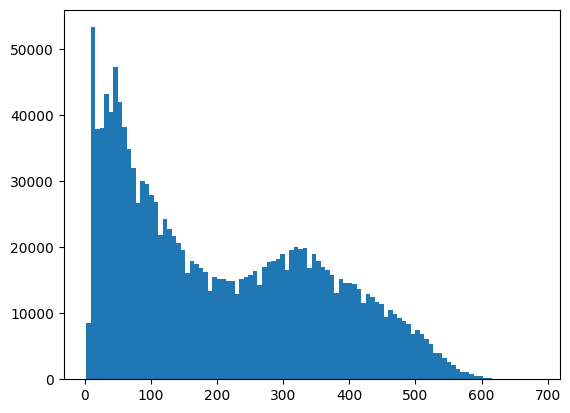

In [117]:
plt.hist(n99_all, bins=100)

{'whiskers': [<matplotlib.lines.Line2D at 0x1a68044bc50>,
 'caps': [<matplotlib.lines.Line2D at 0x1a68044bed0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1a68044bb10>],
 'medians': [<matplotlib.lines.Line2D at 0x1a680488190>],
 'fliers': [<matplotlib.lines.Line2D at 0x1a6804882d0>],
 'means': []}

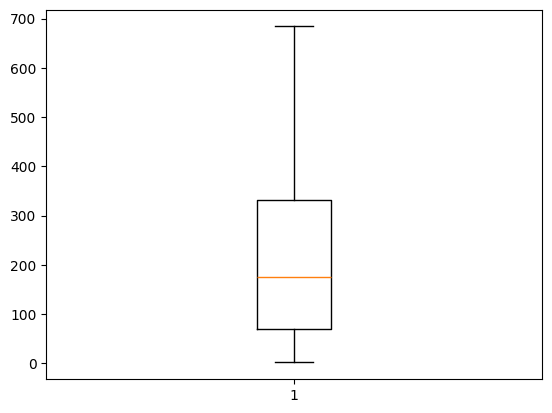

In [118]:
plt.boxplot(n99_all)

In [115]:
window_energies = np.array(window_energies)

print("Min:", window_energies.min())
print("Median:", np.median(window_energies))
print("95th percentile:", np.percentile(window_energies, 95))

Min: 9.7837634e-05
Median: 0.0007350943
95th percentile: 0.011405844


In [104]:
from pathlib import Path
import numpy as np
import librosa


# ------------------------------------------------------------------
# Parameters
# ------------------------------------------------------------------
frame_size = 1024
hop = 512

original_folder = Path(r"C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Audio")
reconstructed_folder = Path(r"E:\AIMS_dataset\bioacoustics_compression\data\Gibbon\Compressed_Audio\cs_reconstructed_0.3")
test_txt = Path(r"C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\DataFiles\test.txt")


# ------------------------------------------------------------------
# Read test filenames
# ------------------------------------------------------------------
with open(test_txt, "r") as f:
    test_files = [line.strip() for line in f if line.strip()]


# ------------------------------------------------------------------
# Helper
# ------------------------------------------------------------------
def segment_signal(signal, frame_size, hop):
    """Return overlapping frames."""
    frames = []

    for start in range(0, len(signal) - frame_size + 1, hop):
        frames.append(signal[start:start + frame_size])

    return np.asarray(frames)


# ------------------------------------------------------------------
# Statistics
# ------------------------------------------------------------------
all_corr = []
all_mse = []

print("-" * 70)

for name in test_files:

    # Load original wav (mono)
    original, sr = librosa.load(
        original_folder / f"{name}.wav",
        sr=None,
    )

    # Find the reconstructed file
    matches = []

    for file in reconstructed_folder.glob("*_reconstructed.npy"):

        stem = file.stem  # remove .npy

        # Remove "_reconstructed"
        stem = stem[:-14]

        # Remove the last "_<number_of_windows>"
        original_name = stem.rsplit("_", 1)[0]

        if original_name == name:
            matches.append(file)

    reconstructed = np.load(matches[0])

    # Ensure same length
    L = min(len(original), len(reconstructed))
    original = original[:L]
    reconstructed = reconstructed[:L]

    # Segment both signals
    frames_original = segment_signal(original, frame_size, hop)
    frames_reconstructed = segment_signal(reconstructed, frame_size, hop)

    n = min(len(frames_original), len(frames_reconstructed))

    file_corr = []
    file_mse = []

    for i in range(n):

        x = frames_original[i]
        y = frames_reconstructed[i]

        corr = np.corrcoef(x, y)[0, 1]
        mse = np.mean((x - y) ** 2)

        file_corr.append(corr)
        file_mse.append(mse)

    file_corr = np.asarray(file_corr)
    file_mse = np.asarray(file_mse)

    print(
        f"{name:40s}"
        f" Corr={file_corr.mean():.4f}"
        f"  MSE={file_mse.mean():.6e}"
    )

    all_corr.extend(file_corr)
    all_mse.extend(file_mse)


all_corr = np.asarray(all_corr)
all_mse = np.asarray(all_mse)

print("\n" + "-" * 70)
print(f"Total windows : {len(all_corr)}")
print(f"Mean corr     : {all_corr.mean():.4f}")
print(f"Std corr      : {all_corr.std():.4f}")
print(f"Min corr      : {all_corr.min():.4f}")
print(f"Max corr      : {all_corr.max():.4f}")
print()
print(f"Mean MSE      : {all_mse.mean():.6e}")
print(f"Std MSE       : {all_mse.std():.6e}")

----------------------------------------------------------------------
HGSM3SOL_0+1_20160309_055600             Corr=0.7865  MSE=4.737841e-04
HGSM3SOL_0+1_20160309_055600_1           Corr=0.8127  MSE=4.156327e-04
HGSM3BD_0+1_20160706_051100_1            Corr=0.7044  MSE=2.315267e-03
HGSM3BD_0+1_20160706_051100_2            Corr=0.7148  MSE=1.071307e-03
HGSM3AB_0+1_20160310_055600              Corr=0.7414  MSE=6.177930e-04
HGSM3C_0+1_20150806_052100               Corr=0.9398  MSE=7.201407e-04
HGSM3C_0+1_20150806_052100_1             Corr=0.9063  MSE=1.400180e-03
HGSM3AB_0+1_20160304_060000              Corr=0.7313  MSE=6.095861e-04
HGSM3BD_0+1_20160702_050900              Corr=0.7406  MSE=1.615376e-03
HGSM3C_0+1_20150811_052300               Corr=0.8521  MSE=7.135984e-04
HGSM3C_0+1_20150811_052300_1             Corr=0.9032  MSE=1.207436e-03
HGSM3C_0+1_20150811_052300_2             Corr=0.9351  MSE=1.454738e-03
HGSM3AB_0+1_20160331_053800              Corr=0.8391  MSE=7.198432e-04

-----

In [105]:
config.data.species_folder=r"E:\AIMS_dataset\bioacoustics_compression\data\Gibbon"

config.preprocessing.audio_extension=".npy"

method_compression="cs"
parameter_compression="0.3"

In [106]:
X_test_cs, Y_test_cs= load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="test", method_compression=method_compression, parameter_compression=parameter_compression)
X_test, Y_test= load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="test", method_compression=None, parameter_compression=None)


Dataset loaded from E:\AIMS_dataset\bioacoustics_compression\data\Gibbon/test_cs_0.3
Dataset loaded from E:\AIMS_dataset\bioacoustics_compression\data\Gibbon/test_baseline


In [107]:
index_positive=np.where(np.argmax(Y_test, axis=1)==1)[0]
index_negative=np.where(np.argmax(Y_test, axis=1)==0)[0]

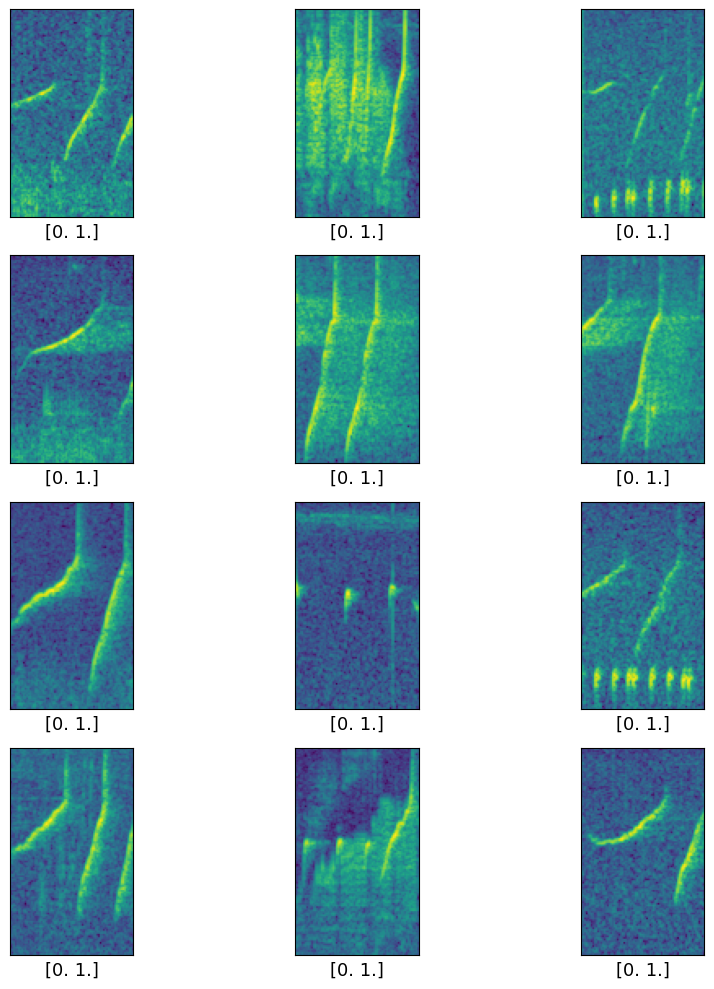

In [108]:
import matplotlib.pyplot as plt


index_n=np.random.choice(index_negative, size=12, replace=False)
index_p=np.random.choice(index_positive, size=12, replace=False)

fig = plt.figure(figsize=(10,10))
w=0
for i in index_p:
    plt.subplot(4,3,w+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_test[i],  origin='lower')
    plt.xlabel(Y_test[i], fontsize=13)
    w+=1
plt.tight_layout()



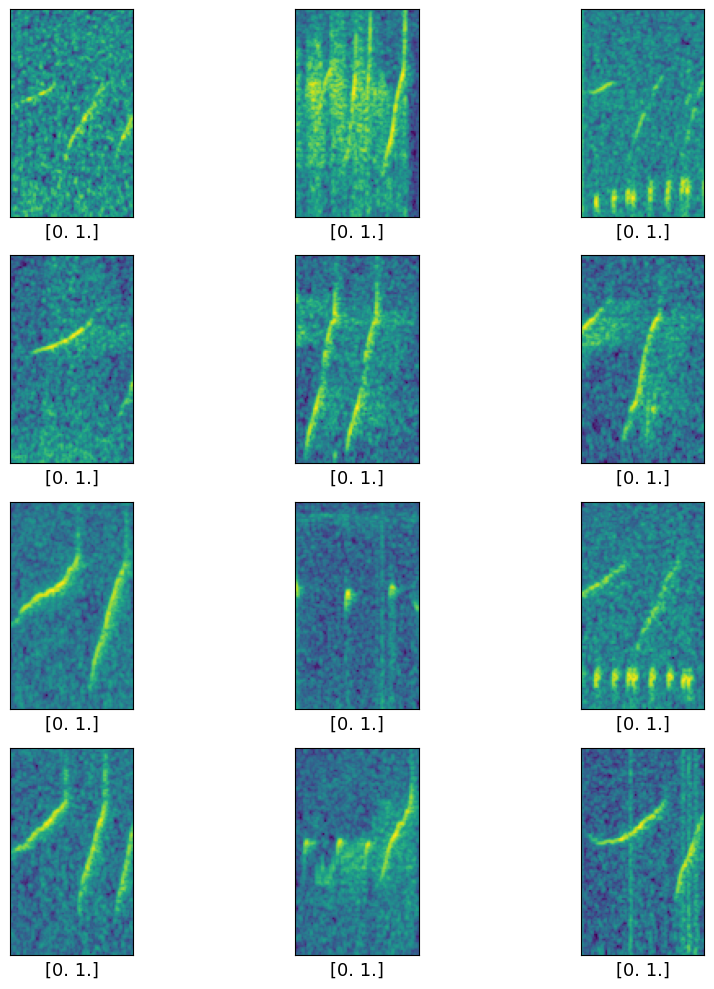

In [109]:
fig = plt.figure(figsize=(10,10))
w=0
for i in index_p:
    plt.subplot(4,3,w+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_test_cs[i],  origin='lower')
    plt.xlabel(Y_test_cs[i], fontsize=13)
    w+=1
plt.tight_layout()

In [110]:
import numpy as np

correlations = []
mse_list = []

for spec_org, spec_cs in zip(X_test, X_test_cs):

    # Flatten the spectrograms
    x = spec_org.ravel()
    y = spec_cs.ravel()

    # Pearson correlation
    corr = np.corrcoef(x, y)[0, 1]
    correlations.append(corr)

    # MSE
    mse = np.mean((x - y) ** 2)
    mse_list.append(mse)

print(f"Mean correlation : {np.mean(correlations):.4f}")
print(f"Std correlation  : {np.std(correlations):.4f}")
print(f"Mean MSE         : {np.mean(mse_list):.6f}")

Mean correlation : 0.5358
Std correlation  : 0.2414
Mean MSE         : 0.020287


In [111]:
from collections import defaultdict

corr_per_class = defaultdict(list)

for spec_org, spec_cs, label in zip(
        X_test,
        X_test_cs,
        np.argmax(Y_test, axis=1)):

    corr = np.corrcoef(spec_org.ravel(), spec_cs.ravel())[0, 1]
    corr_per_class[label].append(corr)

for label in sorted(corr_per_class):
    values = corr_per_class[label]
    print(f"{label}: {np.mean(values):.4f} ± {np.std(values):.4f}")

0: 0.2687 ± 0.1613
1: 0.6492 ± 0.1697


In [112]:
from skimage.metrics import structural_similarity as ssim

ssim_values = []

for spec_org, spec_cs in zip(X_test, X_test_cs):

    score = ssim(
        spec_org,
        spec_cs,
        data_range=spec_org.max() - spec_org.min()
    )

    ssim_values.append(score)

print(f"Mean SSIM: {np.mean(ssim_values):.4f}")

Mean SSIM: 0.3237


In [2]:
import numpy as np
file=r"C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Compressed_Audio\cs_reconstructed_0.3_npy\HGSM3AB_0+1_20160310_055600_195526_reconstructed.npy"
audio=np.load(file)
print(audio.dtype)

float64


In [3]:
import numpy as np
file=r"C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Compressed_Audio\cs_reconstructed_0.4\HGSM3C_0+1_20150812_052300_reconstructed.npy"
audio=np.load(file)
print(audio.dtype)

float32


## explore window size and overlap


In [2]:
import sys
from pathlib import Path

# Add src/ to sys.path regardless of where Jupyter is launched from
for _candidate in [Path().resolve().parent / "src", Path().resolve() / "src"]:
    if _candidate.exists() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        print(f"Added to sys.path: {_candidate}")
        break

In [3]:
import itertools
import re
import pandas as pd
from pathlib import Path
import librosa
from compress import CS
import os
import pickle
import numpy as np
from skimage.metrics import structural_similarity


In [4]:
#parameters species
folder_audio=Path("C:/Users/loren/Documents/Postdoc/Compressed_sensing/Data/Gibbon/Audio")
folder_saved_based=Path("C:/Users/loren/Documents/Postdoc/Compressed_sensing/Data/Gibbon/Compressed_Audio")
folder_tracking=Path("C:/Users/loren/Documents/Postdoc/Compressed_sensing/Data/Gibbon/tracking")

sample_rate=9600    
n_jobs=os.cpu_count() - 4   # raw bat recording sample rate (256 kHz)

compression_rate=0.4

In [5]:
file_name_no_extension="HGSM3B_0+1_20160315_055200_1"
file=file_name_no_extension+".WAV"
audio, sample_rate = librosa.load(Path(folder_audio, file),sr=None)

In [6]:

def compute_mse(original, reconstructed):

    length = min(len(original), len(reconstructed))

    original = original[:length]
    reconstructed = reconstructed[:length]

    return np.mean((original - reconstructed) ** 2)

In [7]:
def compute_waveform_corr(original, reconstructed):

    length = min(len(original), len(reconstructed))

    original = original[:length]
    reconstructed = reconstructed[:length]

    return np.corrcoef(original, reconstructed)[0,1]

In [8]:


def split_audio(audio, sr, window_duration):
    """
    Split audio into non-overlapping windows.

    Parameters
    ----------
    audio : np.ndarray
    sr : int
    window_duration : float
        Window duration in seconds.

    Returns
    -------
    list[np.ndarray]
    """

    window_size = int(window_duration * sr)

    n_windows = len(audio) // window_size

    return [
        audio[i * window_size:(i + 1) * window_size]
        for i in range(n_windows)
    ]

In [9]:
def compute_mean_mel_corr(
        original,
        reconstructed,
        sr,
        window_duration=4,
        n_fft=1024,
        hop_length=256,
        f_min=1000,
        f_max=2000,
        n_mels=128):

    length = min(len(original), len(reconstructed))

    original = original[:length]
    reconstructed = reconstructed[:length]

    windows_original = split_audio(
        original,
        sr,
        window_duration
    )

    windows_reconstructed = split_audio(
        reconstructed,
        sr,
        window_duration
    )

    correlations = []

    for x, y in zip(windows_original,
                    windows_reconstructed):

        mel_x = librosa.feature.melspectrogram(
            y=x,
            sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
            fmin=f_min,
            fmax=f_max,
            power=2,
        )

        mel_y = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
            fmin=f_min,
            fmax=f_max,
            power=2,
        )

        mel_x = librosa.power_to_db(mel_x)

        mel_y = librosa.power_to_db(mel_y)

        corr = np.corrcoef(
            mel_x.ravel(),
            mel_y.ravel()
        )[0, 1]

        correlations.append(corr)

    return (
        np.mean(correlations),
        np.std(correlations),
        correlations
    )

In [9]:
def compute_mean_mel_ssim(
        original,
        reconstructed,
        sr,
        window_duration=4,
        n_fft=1024,
        hop_length=256,
        f_min=1000,
        f_max=2000,
        n_mels=128):

    length = min(len(original), len(reconstructed))

    original = original[:length]
    reconstructed = reconstructed[:length]

    windows_original = split_audio(
        original,
        sr,
        window_duration
    )

    windows_reconstructed = split_audio(
        reconstructed,
        sr,
        window_duration
    )

    ssim_scores = []

    for x, y in zip(windows_original,
                    windows_reconstructed):

        mel_x = librosa.feature.melspectrogram(
            y=x,
            sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
            fmin=f_min,
            fmax=f_max,
            power=2,
        )

        mel_y = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
            fmin=f_min,
            fmax=f_max,
            power=2,
        )

        mel_x = librosa.power_to_db(mel_x)

        mel_y = librosa.power_to_db(mel_y)

        # Normalise each spectrogram independently
        mel_x = (mel_x - mel_x.min()) / (mel_x.max() - mel_x.min() + 1e-12)
        mel_y = (mel_y - mel_y.min()) / (mel_y.max() - mel_y.min() + 1e-12)

        score = structural_similarity(
            mel_x,
            mel_y,
            data_range=1.0
        )

        ssim_scores.append(score)

    return (
        np.mean(ssim_scores),
        np.std(ssim_scores),
        ssim_scores
    )

In [10]:


frame_sizes = [1024, 2048, 4096]
overlaps = [0.0, 0.25, 0.5]

results = []

for frame_size, overlap in itertools.product(frame_sizes,
                                             overlaps):

    if overlap == 0:
        window = "rect"

    elif overlap == 0.25:
        window = "tukey"

    else:
        window = "hann"

    print("=" * 60)
    print(
        f"Frame={frame_size} "
        f"Overlap={overlap} "
        f"Window={window}"
    )

    folder_saved=Path(folder_saved_based, f'cs_{frame_size}_{overlap}')
    folder_saved.mkdir(parents=True, exist_ok=True)

    cs = CS(
        folder_audio,
        folder_saved,
        sample_rate,
        frame_size,
        overlap,
        compression_rate=compression_rate,
        n_jobs=n_jobs,
        window_type=window
    )

    idx = cs.compress_matrix_1D()

    with open(Path(cs.folder_compressed_saved,
                   "idx_matrix.pkl"), "wb") as f:

        pickle.dump(idx, f)

    cs.compress_one_file(
        audio,
        sample_rate,
        idx,
        file_name_no_extension
    )

    cs.reconstruction(
        solver="lasso",
        alpha=1e-7,
        saved_in_wav=True
    )


Frame=1024 Overlap=0.0 Window=rect
folder where to save :  C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Compressed_Audio\cs_1024_0.0\cs_reconstructed_0.4
HGSM3B_0+1_20160315_055200_1_4800


100%|██████████| 4800/4800 [03:11<00:00, 25.09it/s]


Frame=1024 Overlap=0.25 Window=tukey
folder where to save :  C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Compressed_Audio\cs_1024_0.25\cs_reconstructed_0.4
HGSM3B_0+1_20160315_055200_1_6399


100%|██████████| 6399/6399 [04:09<00:00, 25.62it/s]


Frame=1024 Overlap=0.5 Window=hann
folder where to save :  C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Compressed_Audio\cs_1024_0.5\cs_reconstructed_0.4
HGSM3B_0+1_20160315_055200_1_9599


...

100%|██████████| 1200/1200 [09:15<00:00,  2.16it/s]


Frame=4096 Overlap=0.25 Window=tukey
folder where to save :  C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Compressed_Audio\cs_4096_0.25\cs_reconstructed_0.4
HGSM3B_0+1_20160315_055200_1_1599


100%|██████████| 1599/1599 [12:23<00:00,  2.15it/s]


Frame=4096 Overlap=0.5 Window=hann
folder where to save :  C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Compressed_Audio\cs_4096_0.5\cs_reconstructed_0.4
HGSM3B_0+1_20160315_055200_1_2399


100%|██████████| 2399/2399 [18:45<00:00,  2.13it/s]


In [19]:


results = []

folder_experiments = Path(folder_saved_based)      # contains cs_1024_0.0, cs_1024_0.25, ...

compression_rate = 0.4

experiment_folders = sorted(
    f for f in folder_experiments.iterdir()
    if f.is_dir() and f.name.startswith("cs_")
)

for exp in experiment_folders:

    print(f"\nProcessing {exp.name}")

    # ---------------------------------------
    # Read parameters from folder name
    # ---------------------------------------

    m = re.match(r"cs_(\d+)_(\d+\.\d+)", exp.name)

    if m is None:
        print(f"Skipping {exp.name}")
        continue

    frame_size = int(m.group(1))
    overlap = float(m.group(2))

    reconstructed_folder = exp / f"cs_reconstructed_{compression_rate}"

    reconstructed_files = sorted(
        reconstructed_folder.glob("*_reconstructed.wav")
    )

    for reconstructed_file in reconstructed_files:

        stem = reconstructed_file.stem.replace("_reconstructed", "")

        # Remove the last "_6299"
        original_stem = stem.rsplit("_", 1)[0]

        possible_files = [
            folder_audio / f"{original_stem}.WAV",
            folder_audio / f"{original_stem}.wav",
        ]

        original_file = next((f for f in possible_files if f.exists()), None)

        if original_file is None:
            print(f"Missing original: {original_stem}")
            continue


        print(original_file)

        if not original_file.exists():
            original_file = folder_audio / original_name.lower()

        if not original_file.exists():
            print(f"Missing original: {original_name}")
            continue

        original, sr = librosa.load(original_file, sr=None)
        reconstructed, _ = librosa.load(reconstructed_file, sr=None)

        mse = compute_mse(original, reconstructed)

        corr = compute_waveform_corr(original, reconstructed)

        mel_corr_mean, mel_corr_std, _ = compute_mean_mel_corr(
            original,
            reconstructed,
            sr
        )

        ssim_mean, ssim_std, _ = compute_mean_mel_ssim(
            original,
            reconstructed,
            sr
        )

        results.append({

            "file": original_file.name,

            "frame_size": frame_size,

            "overlap": overlap,

            "mse": mse,

            "wave_corr": corr,

            "mel_corr_mean": mel_corr_mean,

            "mel_corr_std": mel_corr_std,

            "ssim_mean": ssim_mean,

            "ssim_std": ssim_std

        })

df = pd.DataFrame(results)

print(df.head())

df.to_csv("cs_window_overlap_results.csv", index=False)


Processing cs_0.4
Skipping cs_0.4

Processing cs_0.4_copy - Copy
Skipping cs_0.4_copy - Copy

Processing cs_1024_0.0
C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Audio\HGSM3B_0+1_20160315_055200_1.WAV
C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Audio\HGSM3B_0+1_20160329_054000.WAV

Processing cs_1024_0.25
C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Audio\HGSM3B_0+1_20160315_055200_1.WAV
C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Audio\HGSM3B_0+1_20160329_054000.WAV

Processing cs_1024_0.5
C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Audio\HGSM3B_0+1_20160315_055200_1.WAV
C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Audio\HGSM3B_0+1_20160329_054000.WAV

Processing cs_2048_0.0
C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Audio\HGSM3B_0+1_20160315_055200_1.WAV
C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Audio\HGSM3B_0+1_20160329_0540

In [20]:
df

,file,frame_size,overlap,mse,wave_corr,mel_corr_mean,mel_corr_std,ssim_mean,ssim_std
0,HGSM3B_0+1_20160315_055200_1.WAV,1024,0.00,0.000404,0.820779,0.258776,0.178621,0.196289,0.055107
1,HGSM3B_0+1_20160329_054000.WAV,1024,0.00,0.000515,0.983883,0.319167,0.223805,0.193254,0.075447
2,HGSM3B_0+1_20160315_055200_1.WAV,1024,0.25,0.000403,0.830576,0.279449,0.183648,0.204604,0.058957
3,HGSM3B_0+1_20160329_054000.WAV,1024,0.25,0.000490,0.987060,0.356147,0.224347,0.204520,0.077218
4,HGSM3B_0+1_20160315_055200_1.WAV,1024,0.50,0.000402,0.855817,0.318520,0.187167,0.234258,0.061700
5,HGSM3B_0+1_20160329_054000.WAV,1024,0.50,0.000458,0.990961,0.392402,0.229020,0.230008,0.086094
6,HGSM3B_0+1_20160315_055200_1.WAV,2048,0.00,0.000403,0.832031,0.279446,0.193417,0.207992,0.058389
7,HGSM3B_0+1_20160329_054000.WAV,2048,0.00,0.000440,0.993015,0.360267,0.234108,0.210454,0.078666
8,HGSM3B_0+1_20160315_055200_1.WAV,2048,0.25,0.000403,0.846127,0.296602,0.193693,0.219493,0.061635
9,HGSM3B_0+1_20160329_054000.WAV,2048,0.25,0.000431,0.994135,0.389197,0.232461,0.227054,0.080096
